In [21]:
# Importing all the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import lightgbm as lgb
import math

In [22]:
# Load data from the three parkmeters
df_500 = pd.read_csv('DataParkmeter500.csv')
df_515 = pd.read_csv('DataParkmeter515.csv')
df_521 = pd.read_csv('DataParkmeter521.csv')

print("Data loaded successfully")

/tmp/ipykernel_3971/3793477124.py:2: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df_500 = pd.read_csv('DataParkmeter500.csv')
/tmp/ipykernel_3971/3793477124.py:3: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df_515 = pd.read_csv('DataParkmeter515.csv')


Data loaded successfully


/tmp/ipykernel_3971/3793477124.py:4: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df_521 = pd.read_csv('DataParkmeter521.csv')


In [23]:
# We have columns dataNoise0 up to dataNoise76
noise_cols = [f'dataNoise{i}' for i in range(77)]

# The formula requires us to multiply the count by (l + 35)
multipliers = np.array([l + 35 for l in range(77)])

def calc_avg_noise(df):
  # Calculate denominator: total count of readings
    denominator = df[noise_cols].sum(axis=1)
    # Calculate numerator: sum of (count * (index + 35))
    numerator = (df[noise_cols] * multipliers).sum(axis=1)
    # Divide them to get the average noise, handling zeros to avoid errors
    return numerator / denominator.replace(0, np.nan)

# Run this calculation for all three datasets
df_500['avg_noise'] = calc_avg_noise(df_500)
df_515['avg_noise'] = calc_avg_noise(df_515)
df_521['avg_noise'] = calc_avg_noise(df_521)

In [24]:
def process_time(df):
    # Convert the timestamp and strip the timezone so Pandas behaves
    df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True).dt.tz_localize(None)
    df.set_index('timestamp', inplace=True)

    # Group by hour and take the mean
    df_hourly = df[['avg_noise']].resample('1h').mean()

    # Instead of strict date filtering, let's just drop the empty rows.
    # This guarantees your dataframe will never be empty.
    df_filtered = df_hourly.dropna()

    return df_filtered

# Apply this safely to all three
df_500_hourly = process_time(df_500)
df_515_hourly = process_time(df_515)
df_521_hourly = process_time(df_521)

print("Step 4 complete! Let's check how many hours we have:")
print(f"500: {len(df_500_hourly)}, 515: {len(df_515_hourly)}, 521: {len(df_521_hourly)}")

Step 4 complete! Let's check how many hours we have:
500: 7099, 515: 10187, 521: 8335


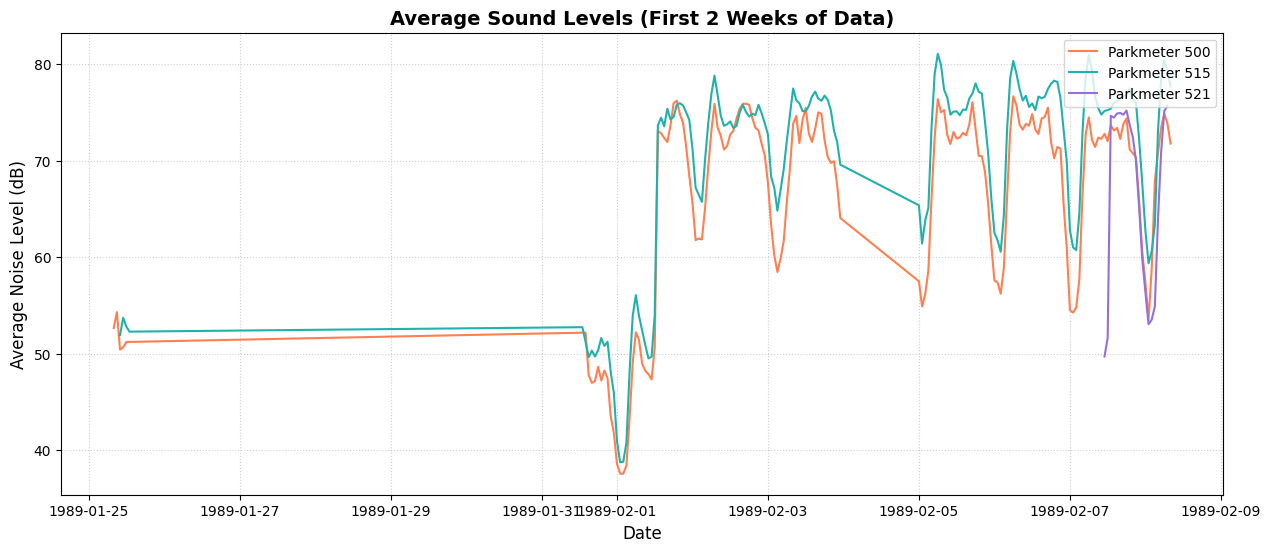

In [25]:
plt.figure(figsize=(15, 6))

# Grab the absolute first timestamp available in the 500 dataset
slice_start = df_500_hourly.index[0]

# Add exactly 14 days to it for our 2-week window
slice_end = slice_start + pd.Timedelta(days=14)

# Plotting the data
plt.plot(df_500_hourly.loc[slice_start:slice_end].index, df_500_hourly.loc[slice_start:slice_end]['avg_noise'], label='Parkmeter 500', color='#FF7F50', linewidth=1.5)
plt.plot(df_515_hourly.loc[slice_start:slice_end].index, df_515_hourly.loc[slice_start:slice_end]['avg_noise'], label='Parkmeter 515', color='#20B2AA', linewidth=1.5)
plt.plot(df_521_hourly.loc[slice_start:slice_end].index, df_521_hourly.loc[slice_start:slice_end]['avg_noise'], label='Parkmeter 521', color='#9370DB', linewidth=1.5)

plt.title('Average Sound Levels (First 2 Weeks of Data)', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Average Noise Level (dB)', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [26]:
# The paper only uses terminal 515 for the ML models
data_515 = df_515_hourly[['avg_noise']].values

# Normalize the data using MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data_515)

# Splitting data: 90% for training, 10% for testing the model
train_size = int(len(scaled_data) * 0.90)
train_data = scaled_data[:train_size]
test_data = scaled_data[train_size:]

print(f"Training on {len(train_data)} hours, testing on {len(test_data)} hours.")

Training on 9168 hours, testing on 1019 hours.


In [27]:
# Function to prep time series data using a sliding window
def create_dataset(dataset, look_back=12):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

# Let's use 12 hours of past data to predict the next hour
look_back = 12
X_train, y_train = create_dataset(train_data, look_back)
X_test, y_test = create_dataset(test_data, look_back)

In [28]:
#config 1 setup, setting up LightGBM with the first set of hyperparameters from Table 2
model_config1 = lgb.LGBMRegressor(num_leaves=11, learning_rate=0.05, n_estimators=500)

# Training the first model
model_config1.fit(X_train, y_train)

# Getting the predictions to check the error later
train_predict1 = model_config1.predict(X_train)
test_predict1 = model_config1.predict(X_test)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001079 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3060
[LightGBM] [Info] Number of data points in the train set: 9156, number of used features: 12
[LightGBM] [Info] Start training from score 0.713153


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [29]:
#config 2 setup, setting up LightGBM with the second config from the paper
model_config2 = lgb.LGBMRegressor(num_leaves=11, learning_rate=0.04, n_estimators=1000)

# Training the second model
model_config2.fit(X_train, y_train)

# Getting predictions
train_predict2 = model_config2.predict(X_train)
test_predict2 = model_config2.predict(X_test)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001438 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3060
[LightGBM] [Info] Number of data points in the train set: 9156, number of used features: 12
[LightGBM] [Info] Start training from score 0.713153


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [30]:
# Quick function to scale the decibels back to normal numbers
def inverse(data):
    return scaler.inverse_transform(data.reshape(-1, 1))

y_train_inv = inverse(y_train)
y_test_inv = inverse(y_test)

# Calculate RMSE for Config 1
rmse1_train = math.sqrt(mean_squared_error(y_train_inv, inverse(train_predict1)))
rmse1_test = math.sqrt(mean_squared_error(y_test_inv, inverse(test_predict1)))

# Calculate RMSE for Config 2
rmse2_train = math.sqrt(mean_squared_error(y_train_inv, inverse(train_predict2)))
rmse2_test = math.sqrt(mean_squared_error(y_test_inv, inverse(test_predict2)))

print(f"Config 1 -> Train RMSE: {rmse1_train:.2f}, Test RMSE: {rmse1_test:.2f}")
print(f"Config 2 -> Train RMSE: {rmse2_train:.2f}, Test RMSE: {rmse2_test:.2f}")

Config 1 -> Train RMSE: 1.12, Test RMSE: 1.33
Config 2 -> Train RMSE: 1.04, Test RMSE: 1.32


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/v

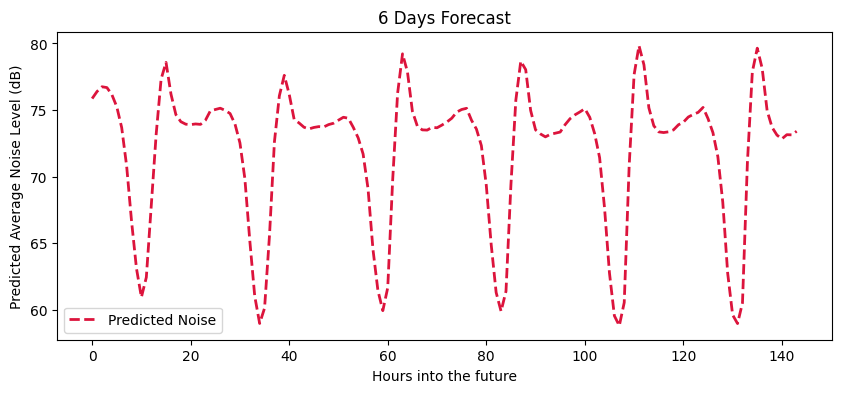


Testing FDIA Detection
Predicted Noise: 75.30 dB
Hacked Sensor Reading: 83.13 dB
Difference: 7.84 dB
ALARM: False Data Injection Attack Detected.Difference greater than 5 dB


In [31]:
# Use the second configuration
best_model = model_config2

# Get the last 12 hours of data to start our predictions
current_input = test_data[-look_back:].flatten()
forecast = []

# Predict the next 6 days (which is 144 hours)
for i in range(144):
    # Predict the next hour
    pred = best_model.predict(current_input.reshape(1, -1))[0]
    forecast.append(pred)

    # Shift the window forward to include the new prediction
    current_input = np.append(current_input[1:], pred)

# Change the scaled values back to actual decibels
forecast_inv = inverse(np.array(forecast))

# Plot the 6-day forecast curve
plt.figure(figsize=(10, 4))
plt.plot(forecast_inv, color='#DC143C', linestyle='--', linewidth=2, label='Predicted Noise')
plt.title('6 Days Forecast')
plt.xlabel('Hours into the future')
plt.ylabel('Predicted Average Noise Level (dB)')
plt.legend()
plt.show()

#False Data Injection Attack (FDIA) Detection
# The paper states an attack is detected if the difference between
# the predicted value and the real sensor reading is over 5 dB

print("\nTesting FDIA Detection")

# Grab the final prediction and the final real value from our test set
predicted_val = inverse(test_predict2[-1:])[0][0]
real_sensor_val = inverse(y_test[-1:])[0][0]

# Simulate a false data attack by adding 8 dB to the real reading
hacked_sensor_val = real_sensor_val + 8.0

# Find the absolute difference
difference = abs(hacked_sensor_val - predicted_val)

print(f"Predicted Noise: {predicted_val:.2f} dB")
print(f"Hacked Sensor Reading: {hacked_sensor_val:.2f} dB")
print(f"Difference: {difference:.2f} dB")

# Check if the difference passes the 5 dB threshold
threshold = 5.0

if difference > threshold:
    print("ALARM: False Data Injection Attack Detected.Difference greater than 5 dB")
else:
    print("Sensor data looks normal")

In [32]:
from keras.models import Sequential
from keras.layers import LSTM, Dense

# LSTMs need the data shaped as [samples, time steps, features]
X_train_lstm = np.reshape(X_train, (X_train.shape[0], 1, X_train.shape[1]))
X_test_lstm = np.reshape(X_test, (X_test.shape[0], 1, X_test.shape[1]))

# Build the Stacked-LSTM, similar to the paper's architecture
lstm_model = Sequential()
lstm_model.add(LSTM(150, return_sequences=True, input_shape=(1, look_back)))
lstm_model.add(LSTM(100))
lstm_model.add(Dense(1))

# The paper used Nadam/RMSprop
lstm_model.compile(loss='mean_squared_error', optimizer='nadam')

# Train
print("Training Stacked LSTM")
lstm_model.fit(X_train_lstm, y_train, epochs=25, batch_size=64, verbose=0)

# Predict and get RMSE
lstm_test_pred = lstm_model.predict(X_test_lstm)
lstm_rmse = math.sqrt(mean_squared_error(y_test_inv, inverse(lstm_test_pred)))

print(f"Stacked-LSTM Test RMSE: {lstm_rmse:.2f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Training Stacked LSTM
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Stacked-LSTM Test RMSE: 1.62
